# Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

listings_rec = pd.read_csv('listings_rec.csv')
print(f'Loaded {len(listings_rec)} listings')
print(listings_rec[['price_log', 'has_reviews', 'review_scores_rating', 'minimum_nights']].head())

Loaded 36613 listings
   price_log  has_reviews  review_scores_rating  minimum_nights
0   4.454347            1                  4.89              30
1   5.484797            1                  4.68              30
2   5.379897            1                  4.75              30
3   4.574711            1                  4.58              30
4   4.094345            1                  5.00              30


In [8]:
# define feature columns
feature_cols = ['price_log', 'accommodates', 'review_scores_rating',
                'has_reviews', 'minimum_nights', 'room_type',
                'neighbourhood_group_cleansed']

listings_encoded = pd.get_dummies(
    listings_rec[feature_cols + ['id']],
    columns=['room_type', 'neighbourhood_group_cleansed'],
    drop_first=False
)

# normalise
scaler = StandardScaler()
feature_matrix = scaler.fit_transform(listings_encoded.drop('id', axis=1))

print(f'Feature matrix shape: {feature_matrix.shape}')
print(f'Columns: {list(listings_encoded.drop("id", axis=1).columns)}')

feature_columns = list(listings_encoded.drop('id', axis=1).columns)
print(feature_columns)

Feature matrix shape: (36613, 14)
Columns: ['price_log', 'accommodates', 'review_scores_rating', 'has_reviews', 'minimum_nights', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Bronx', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island']
['price_log', 'accommodates', 'review_scores_rating', 'has_reviews', 'minimum_nights', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_cleansed_Bronx', 'neighbourhood_group_cleansed_Brooklyn', 'neighbourhood_group_cleansed_Manhattan', 'neighbourhood_group_cleansed_Queens', 'neighbourhood_group_cleansed_Staten Island']


# Recommender

In [9]:
def recommend_listings(user_prefs, feature_matrix, listings_rec, 
                       feature_columns, scaler, top_n=5):
   
    query = pd.DataFrame(0, index=[0], columns=feature_columns)

    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    query_scaled = scaler.transform(query)

    similarities = cosine_similarity(query_scaled, feature_matrix)[0]
    
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
    'id', 'price', 'room_type',
    'neighbourhood_group_cleansed',
    'review_scores_rating',
    'accommodates',
    'minimum_nights',
    'estimated_occupancy_l365d'
]].copy()
    
    results['similarity_score'] = similarities[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Recommender is ready')

Recommender is ready


# Sample Users Test

In [39]:
cols = ['price', 'room_type', 'neighbourhood_group_cleansed',
        'review_scores_rating', 'minimum_nights', 'estimated_occupancy_l365d',
        'similarity_score']

# budget private room in Brooklyn
user_1 = {
    'price_log': np.log1p(80),
    'accommodates': 2,
    'review_scores_rating': 4.8,
    'has_reviews': 1,
    'minimum_nights': 2,
    'room_type_Private room': 1,
    'neighbourhood_group_cleansed_Brooklyn': 1
}
results_1 = recommend_listings(user_1, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('budget private room in Brooklyn')
print(results_1[cols])
print()



budget private room in Brooklyn
   price     room_type neighbourhood_group_cleansed  review_scores_rating  \
0   85.0  Private room                     Brooklyn                  4.80   
1   85.0  Private room                     Brooklyn                  4.80   
2   85.0  Private room                     Brooklyn                  4.80   
3   86.0  Private room                     Brooklyn                  4.79   
4   86.0  Private room                     Brooklyn                  4.81   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0               2                        255             1.000  
1               3                          0             0.999  
2               1                        255             0.999  
3               3                        255             0.999  
4               1                        218             0.999  



In [40]:
# luxury entire home in Manhattan
user_2 = {
    'price_log': np.log1p(400),
    'accommodates': 4,
    'review_scores_rating': 4.9,
    'has_reviews': 1,
    'minimum_nights': 3,
    'room_type_Entire home/apt': 1,
    'neighbourhood_group_cleansed_Manhattan': 1
}
results_2 = recommend_listings(user_2, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('luxury entire home in Manhattan')
print(results_2[cols])
print()

luxury entire home in Manhattan
   price        room_type neighbourhood_group_cleansed  review_scores_rating  \
0  393.0  Entire home/apt                    Manhattan                  4.90   
1  410.0  Entire home/apt                    Manhattan                  4.92   
2  422.0  Entire home/apt                    Manhattan                  4.93   
3  409.0  Entire home/apt                    Manhattan                  4.87   
4  395.0  Entire home/apt                    Manhattan                  4.94   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0               2                         64             1.000  
1               1                        128             1.000  
2               3                        255             0.999  
3               5                        255             0.999  
4               1                        255             0.999  



In [41]:
# budget shared room in Queens
user_3 = {
    'price_log': np.log1p(50),
    'accommodates': 1,
    'review_scores_rating': 4.5,
    'has_reviews': 0,
    'minimum_nights': 1,
    'room_type_Shared room': 1,
    'neighbourhood_group_cleansed_Queens': 1
}
results_3 = recommend_listings(user_3, feature_matrix, listings_rec,
                               feature_columns, scaler, top_n=5)
print('budget shared room in Queens')
print(results_3[cols])

budget shared room in Queens
   price    room_type neighbourhood_group_cleansed  review_scores_rating  \
0   56.0  Shared room                       Queens                  4.86   
1   56.0  Shared room                       Queens                  4.86   
2   56.0  Shared room                       Queens                  4.86   
3   56.0  Shared room                       Queens                  4.86   
4   33.0  Shared room                       Queens                  4.86   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0              30                          0             0.996  
1              30                          0             0.996  
2              30                          0             0.996  
3              30                          0             0.996  
4              30                          0             0.996  


## Gradient Descent Feature Weighting

The cosine similarity recommender treats all features equally after scaling.
But based on Project 1, the features differ significantly in importance --
review_scores_rating had a t-statistic of 54.5 vs price at 0.18.

Gradient descent targest this by learning the optimal feature weights through minimising the difference
between predicted and actual occupancy.


In [13]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    
    # initialise weights to zero
    weights = np.zeros(X.shape[1])
    loss_history = []
    
    for epoch in range(epochs):
        # forward pass -- predicted occupancy
        y_pred = X @ weights
        
        # compute loss -- mean squared error
        loss = np.mean((y - y_pred) ** 2)
        loss_history.append(loss)
        
        # compute gradient
        gradient = -2/len(y) * X.T @ (y - y_pred)
        
        # update weights
        weights = weights - learning_rate * gradient
        
        # print progress every 200 epochs
        if epoch % 200 == 0:
            print(f'Epoch {epoch}: loss = {loss:.6f}')
    
    return weights, loss_history

In [14]:
# filter to active listings only
active_mask = listings_rec['estimated_occupancy_l365d'] > 0
X_active = feature_matrix[active_mask.values]
y_active = listings_rec.loc[active_mask, 'estimated_occupancy_l365d'].values
y_norm = (y_active - y_active.min()) / (y_active.max() - y_active.min())

print(f'Active listings: {len(X_active)}')
print(f'Inactive excluded: {(~active_mask).sum()}')

Active listings: 11035
Inactive excluded: 25578


In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

# rebuild active mask with index tracking
active_mask = listings_rec['estimated_occupancy_l365d'] > 0
active_indices = listings_rec[active_mask].index.values

X_active = feature_matrix[active_mask.values]
y_active = listings_rec.loc[active_mask, 'estimated_occupancy_l365d'].values
y_norm = (y_active - y_active.min()) / (y_active.max() - y_active.min())

# train/test split WITH index tracking
train_idx, test_idx, X_train, X_test, y_train, y_test = train_test_split(
    active_indices, X_active, y_norm, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Test samples: {len(X_test)}')

print('\nRunning gradient descent on training set...')
weights, loss_history = gradient_descent(X_train, y_train,
                                          learning_rate=0.01, epochs=1500)

y_pred_test = X_test @ weights
test_loss = np.mean((y_test - y_pred_test) ** 2)

print(f'\nTrain loss: {loss_history[-1]:.6f}')
print(f'Test loss:  {test_loss:.6f}')
print(f'Difference: {abs(test_loss - loss_history[-1]):.6f}')

listings_rec_test = listings_rec.loc[test_idx].reset_index(drop=True)
feature_matrix_test = feature_matrix[test_idx]
print(f'Evaluation pool: {len(listings_rec_test)} held-out listings')

Training samples: 8828
Test samples: 2207

Running gradient descent on training set...
Epoch 0: loss = 0.465495
Epoch 200: loss = 0.116146
Epoch 400: loss = 0.109735
Epoch 600: loss = 0.109117
Epoch 800: loss = 0.108957
Epoch 1000: loss = 0.108911
Epoch 1200: loss = 0.108897
Epoch 1400: loss = 0.108893

Train loss: 0.108893
Test loss:  0.117593
Difference: 0.008700
Evaluation pool: 2207 held-out listings


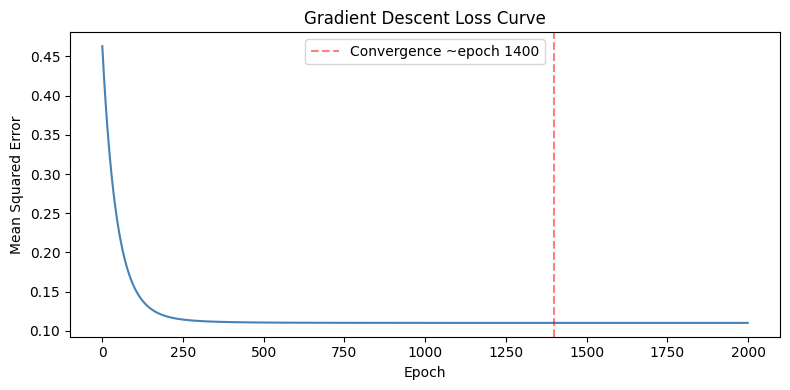

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.title('Gradient Descent Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.axvline(x=1400, color='red', linestyle='--', 
            alpha=0.5, label='Convergence ~epoch 1400')
plt.legend()
plt.tight_layout()
plt.show()

                                       feature    weight
3                                  has_reviews  0.822973
2                         review_scores_rating  0.035492
0                                    price_log  0.022727
10       neighbourhood_group_cleansed_Brooklyn  0.013623
5                    room_type_Entire home/apt  0.009820
8                        room_type_Shared room  0.005931
12         neighbourhood_group_cleansed_Queens  0.002141
7                       room_type_Private room  0.000737
9           neighbourhood_group_cleansed_Bronx -0.002750
13  neighbourhood_group_cleansed_Staten Island -0.003080
11      neighbourhood_group_cleansed_Manhattan -0.013126
1                                 accommodates -0.013318
6                         room_type_Hotel room -0.049343
4                               minimum_nights -0.120158


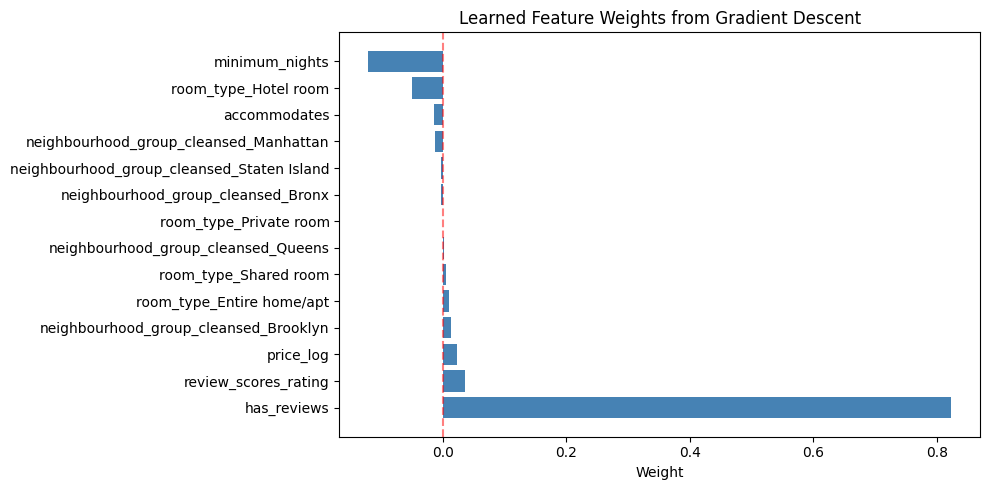

In [36]:
# map weights to feature names
weight_df = pd.DataFrame({
    'feature': feature_columns,
    'weight': weights
}).sort_values('weight', ascending=False)

print(weight_df.to_string())

# plot
plt.figure(figsize=(10, 5))
plt.barh(weight_df['feature'], weight_df['weight'], color='steelblue')
plt.title('Learned Feature Weights from Gradient Descent')
plt.xlabel('Weight')
plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Learned weights align with Project 1 findings

Gradient descent helped confirm Project 1 OLS results:
- review_scores_rating: positive weight (OLS coef 0.046, t-stat 54.5)
- minimum_nights: strongest negative weight (OLS coef -0.0008, p=0.000)
- has_reviews: dominant predictor -- listings with real reviews 
  show significantly higher occupancy


In [17]:
# check how has_reviews distributes across listings
print('has_reviews distribution:')
print(listings_rec['has_reviews'].value_counts())
print(f'\nhas_reviews weight: {weights[3]:.6f}')
print(f'Next highest weight: {weights[2]:.6f}')
print(f'Ratio: {weights[3]/weights[2]:.1f}x larger')

# check if has_reviews alone predicts occupancy well
reviewed = listings_rec[listings_rec['has_reviews'] == 1]['estimated_occupancy_l365d'].mean()
not_reviewed = listings_rec[listings_rec['has_reviews'] == 0]['estimated_occupancy_l365d'].mean()
print(f'\nAvg occupancy with reviews: {reviewed:.1f} days')
print(f'Avg occupancy without reviews: {not_reviewed:.1f} days')
print(f'Difference: {reviewed - not_reviewed:.1f} days')

has_reviews distribution:
has_reviews
1    25018
0    11595
Name: count, dtype: int64

has_reviews weight: 0.812358
Next highest weight: 0.036980
Ratio: 22.0x larger

Avg occupancy with reviews: 68.3 days
Avg occupancy without reviews: 0.0 days
Difference: 68.3 days


In [18]:
# cap has_reviews weight to zero -- too dominant and it measures activity not quality
weights_adjusted = weights.copy()
weights_adjusted[3] = 0  # index 3 is has_reviews
print('has_reviews weight set to 0')
print(pd.DataFrame({'feature': feature_columns, 
                    'weight': weights_adjusted})
      .sort_values('weight', ascending=False))

has_reviews weight set to 0
                                       feature    weight
2                         review_scores_rating  0.036980
10       neighbourhood_group_cleansed_Brooklyn  0.014832
0                                    price_log  0.014394
5                    room_type_Entire home/apt  0.011720
8                        room_type_Shared room  0.002670
3                                  has_reviews  0.000000
7                       room_type_Private room -0.000496
12         neighbourhood_group_cleansed_Queens -0.000949
13  neighbourhood_group_cleansed_Staten Island -0.004265
9           neighbourhood_group_cleansed_Bronx -0.005006
11      neighbourhood_group_cleansed_Manhattan -0.011076
1                                 accommodates -0.012227
6                         room_type_Hotel room -0.050275
4                               minimum_nights -0.157258


In [20]:
def weighted_recommender(user_prefs, feature_matrix, listings_rec,
                       feature_columns, scaler, weights_adjusted, top_n=5):
    """
    Weighted cosine similarity recommender using learned feature weights.
    Weights learned via gradient descent on active listings.
    has_reviews excluded from weighting -- measures activity not quality.
    """
    # build query vector
    query = pd.DataFrame(0, index=[0], columns=feature_columns)
    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    # scale query
    query_scaled = scaler.transform(query)
    
    # apply learned weights
    query_weighted = query_scaled * weights_adjusted
    matrix_weighted = feature_matrix * weights_adjusted
    
    # compute cosine similarity on weighted vectors
    similarities = cosine_similarity(query_weighted, matrix_weighted)[0]
    
    # get top N
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
        'id', 'price', 'room_type',
        'neighbourhood_group_cleansed',
        'review_scores_rating',
        'accommodates',
        'minimum_nights',
        'estimated_occupancy_l365d'
    ]].copy()
    results['similarity_score'] = similarities[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Weighted recommender is ready.')

Weighted recommender is ready.


In [31]:
# budget private room in Brooklyn
user_1 = {
    'price_log': np.log1p(80),
    'accommodates': 2,
    'review_scores_rating': 4.8,
    'has_reviews': 1,
    'minimum_nights': 2,
    'room_type_Private room': 1,
    'neighbourhood_group_cleansed_Brooklyn': 1
}

eq_results = recommend_listings(user_1, feature_matrix_test, listings_rec_test,
                                feature_columns, scaler, top_n=5)
w_results = weighted_recommender(user_1, feature_matrix_test, listings_rec_test,
                               feature_columns, scaler, weights_adjusted, top_n=5)

cols = ['price', 'room_type', 'neighbourhood_group_cleansed',
        'review_scores_rating', 'minimum_nights',
        'estimated_occupancy_l365d', 'similarity_score']

print('equal weight')
print(eq_results[cols])
print()
print('weighted')
print(w_results[cols])

equal weight
   price     room_type neighbourhood_group_cleansed  review_scores_rating  \
0   85.0  Private room                     Brooklyn                  4.80   
1   73.0  Private room                     Brooklyn                  4.78   
2   81.0  Private room                     Brooklyn                  4.75   
3   88.0  Private room                     Brooklyn                  4.86   
4   70.0  Private room                     Brooklyn                  4.85   

   minimum_nights  estimated_occupancy_l365d  similarity_score  
0               2                        255             1.000  
1               1                        255             0.999  
2               2                        255             0.999  
3               1                        255             0.997  
4               2                        255             0.997  

weighted
   price     room_type neighbourhood_group_cleansed  review_scores_rating  \
0   85.0  Private room                     Broo

In [29]:
def hybrid_recommender(user_prefs, feature_matrix, listings_rec,
                     feature_columns, scaler, weights_adjusted, 
                     alpha=0.7, top_n=5):
    """
    Hybrid recommender combining weighted cosine similarity (70%)
    with occupancy signal from Project 1 findings (30%).
    """
    # build query vector
    query = pd.DataFrame(0, index=[0], columns=feature_columns)
    for key, value in user_prefs.items():
        if key in query.columns:
            query[key] = value
    
    # scale query
    query_scaled = scaler.transform(query)
    
    # weighted cosine similarity
    query_weighted = query_scaled * weights_adjusted
    matrix_weighted = feature_matrix * weights_adjusted
    similarity_scores = cosine_similarity(query_weighted, matrix_weighted)[0]
    
    # normalise occupancy to 0-1
    occ = listings_rec['estimated_occupancy_l365d'].values
    occ_norm = (occ - occ.min()) / (occ.max() - occ.min())
    
    # hybrid score -- 70% similarity, 30% occupancy
    hybrid_scores = (alpha * similarity_scores) + ((1 - alpha) * occ_norm)
    
    top_indices = hybrid_scores.argsort()[::-1][:top_n]
    
    results = listings_rec.iloc[top_indices][[
        'id', 'price', 'room_type',
        'neighbourhood_group_cleansed',
        'review_scores_rating',
        'accommodates',
        'minimum_nights',
        'estimated_occupancy_l365d'
    ]].copy()
    results['similarity_score'] = similarity_scores[top_indices].round(3)
    results['hybrid_score'] = hybrid_scores[top_indices].round(3)
    
    return results.reset_index(drop=True)

print('Hybrid recommender is ready')

Hybrid recommender is ready


In [42]:
cols = ['price', 'room_type', 'neighbourhood_group_cleansed',
        'review_scores_rating', 'minimum_nights',
        'estimated_occupancy_l365d', 'similarity_score', 'hybrid_score']

# hybrid results for user 1
h_results = hybrid_recommender(user_1, feature_matrix_test, listings_rec_test,
                             feature_columns, scaler, weights_adjusted,
                             alpha=0.7, top_n=5)

personas = [
    (user_1, 'budget Brooklyn'),
    (user_2, 'luxury Manhattan'),
    (user_3, 'budget Queens')
]
for user, name in personas:
    eq = recommend_listings(user, feature_matrix_test, listings_rec_test,
                            feature_columns, scaler, top_n=5)
    h = hybrid_recommender(user, feature_matrix_test, listings_rec_test,
                         feature_columns, scaler, weights_adjusted,
                         alpha=0.7, top_n=5)
    print(name)
    print(f'  equal weight avg occupancy : {eq["estimated_occupancy_l365d"].mean():.1f} days')
    print(f'  hybrid avg occupancy       : {h["estimated_occupancy_l365d"].mean():.1f} days')
    print(f'  hybrid avg review score    : {h["review_scores_rating"].mean():.3f}')
    print()

pool_occ = listings_rec_test["estimated_occupancy_l365d"].mean()
pool_rev = listings_rec_test["review_scores_rating"].mean()
print(f'overall pool avg occupancy   : {pool_occ:.1f} days')
print(f'overall pool avg review score: {pool_rev:.3f}')

budget Brooklyn
  equal weight avg occupancy : 255.0 days
  hybrid avg occupancy       : 255.0 days
  hybrid avg review score    : 4.800

luxury Manhattan
  equal weight avg occupancy : 209.4 days
  hybrid avg occupancy       : 255.0 days
  hybrid avg review score    : 4.912

budget Queens
  equal weight avg occupancy : 225.0 days
  hybrid avg occupancy       : 255.0 days
  hybrid avg review score    : 4.764

overall pool avg occupancy   : 153.0 days
overall pool avg review score: 4.758


In [35]:
eq_occ = eq_results["estimated_occupancy_l365d"].mean()
w_occ = w_results["estimated_occupancy_l365d"].mean()
h_occ = h_results["estimated_occupancy_l365d"].mean()
pool_occ = listings_rec_test["estimated_occupancy_l365d"].mean()

eq_rev = eq_results["review_scores_rating"].mean()
w_rev = w_results["review_scores_rating"].mean()
h_rev = h_results["review_scores_rating"].mean()
pool_rev = listings_rec_test["review_scores_rating"].mean()

print('Avg occupancy (days)')
print(f'  Equal weight : {eq_occ:.1f}')
print(f'  Weighted     : {w_occ:.1f}')
print(f'  Hybrid       : {h_occ:.1f}')
print(f'  Pool average : {pool_occ:.1f}')
print()
print('Avg review score')
print(f'  Equal weight : {eq_rev:.3f}')
print(f'  Weighted     : {w_rev:.3f}')
print(f'  Hybrid       : {h_rev:.3f}')
print(f'  Pool average : {pool_rev:.3f}')
print()
print('Improvement vs pool')
print(f'  Equal weight : {eq_occ/pool_occ:.1f}x')
print(f'  Weighted     : {w_occ/pool_occ:.1f}x')
print(f'  Hybrid       : {h_occ/pool_occ:.1f}x')


Avg occupancy (days)
  Equal weight : 255.0
  Weighted     : 227.0
  Hybrid       : 255.0
  Pool average : 153.0

Avg review score
  Equal weight : 4.808
  Weighted     : 4.786
  Hybrid       : 4.800
  Pool average : 4.758

Improvement vs pool
  Equal weight : 1.7x
  Weighted     : 1.5x
  Hybrid       : 1.7x


In [44]:
for user, name in personas:
    h = hybrid_recommender(user, feature_matrix_test, listings_rec_test,
                         feature_columns, scaler, weights_adjusted,
                         alpha=0.7, top_n=5)
    ib_rate = listings_rec_test.iloc[h.index]['instant_bookable'].mean()
    pool_ib = listings_rec_test['instant_bookable'].mean()
    print(f'{name}: {ib_rate:.1%} Instant Book vs {pool_ib:.1%} pool')

budget Brooklyn: 40.0% Instant Book vs 24.6% pool
luxury Manhattan: 40.0% Instant Book vs 24.6% pool
budget Queens: 40.0% Instant Book vs 24.6% pool


In [45]:
# check Instant Book rate in test set specifically
print(f'Instant Book rate in test pool: {listings_rec_test["instant_bookable"].mean():.1%}')
print(f'Instant Book rate in full pool: {listings_rec["instant_bookable"].mean():.1%}')

Instant Book rate in test pool: 24.6%
Instant Book rate in full pool: 20.5%


In [47]:
import pickle

# save everything the app needs
with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'feature_matrix': feature_matrix,
        'feature_columns': feature_columns,
        'weights_adjusted': weights_adjusted,
        'scaler': scaler
    }, f)

print('artifacts saved')

artifacts saved
